In [9]:
import pandas as pd 
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nifty_banks = [
    "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS", "KOTAKBANK.NS", 
    "AXISBANK.NS", "INDUSINDBK.NS", "PNB.NS", "BANKBARODA.NS", 
    "FEDERALBNK.NS", "IDFCFIRSTB.NS"
]

In [74]:
list = []
for banks in nifty_banks:
    df1 = yf.Ticker(banks)
    df2 = df1.history(period='5y')
    df2 = df2.reset_index()
    df2['Date'] = df2['Date'].dt.tz_localize(None)
    df2['Symbol'] = (banks)
    df2 = df2[['Date', 'Symbol', 'Close']].rename(columns={'Close': 'Stock_Close'})
    list.append(df2)
df3 = pd.concat(list)

In [75]:
df3['Stock_Close'] = df3['Stock_Close'].round(2)

In [76]:
df3.head()

,Date,Symbol,Stock_Close
0,2021-03-23,HDFCBANK.NS,710.45
1,2021-03-24,HDFCBANK.NS,700.34
2,2021-03-25,HDFCBANK.NS,693.02
3,2021-03-26,HDFCBANK.NS,706.26
4,2021-03-30,HDFCBANK.NS,735.81


In [77]:
df3['Return'] = df3['Stock_Close'].pct_change()
df3 = df3.dropna()

In [ ]:
df3['Return'] = df3['Return'] * 100
df3['Return'] = df3['Return'].round(2)
df3['Symbol'] = df3['Symbol'].str[:-3]
df3.head()

,Date,Symbol,Stock_Close,Return
1,2021-03-24,HDFCBANK,700.34,-1.42
2,2021-03-25,HDFCBANK,693.02,-1.05
3,2021-03-26,HDFCBANK,706.26,1.91
4,2021-03-30,HDFCBANK,735.81,4.18
5,2021-03-31,HDFCBANK,707.37,-3.87


In [120]:
df4 = df3.pivot(index= 'Date', columns='Symbol', values='Stock_Close')
df4.head()

Symbol,AXISBANK,BANKBARODA,FEDERALBNK,HDFCBANK,ICICIBANK,IDFCFIRSTB,INDUSINDBK,KOTAKBANK,PNB,SBIN
Date,,,,,,,,,,
2021-03-23,727.51,65.82,74.75,NaN,567.16,61.15,956.10,361.02,35.95,343.90
2021-03-24,703.46,63.65,72.31,700.34,548.88,58.56,925.82,355.01,34.33,332.04
2021-03-25,691.71,62.10,72.93,693.02,552.80,57.01,924.95,351.11,32.94,327.75
2021-03-26,695.30,62.72,73.36,706.26,559.57,57.51,920.07,352.74,33.40,329.59
2021-03-30,692.46,64.05,72.45,735.81,572.04,58.06,928.09,354.77,33.54,332.92


In [125]:
cr = df4.corr()
cr = cr.reset_index()
cr

Symbol,Symbol,AXISBANK,BANKBARODA,FEDERALBNK,HDFCBANK,ICICIBANK,IDFCFIRSTB,INDUSINDBK,KOTAKBANK,PNB,SBIN
0,AXISBANK,1.000000,0.961748,0.923873,0.767801,0.906043,0.773284,0.205225,0.419919,0.938014,0.929064
1,BANKBARODA,0.961748,1.000000,0.930291,0.738611,0.915983,0.765178,0.197463,0.379332,0.951980,0.941326
2,FEDERALBNK,0.923873,0.930291,1.000000,0.828838,0.936921,0.614386,-0.070740,0.538539,0.877681,0.973341
3,HDFCBANK,0.767801,0.738611,0.828838,1.000000,0.877604,0.494837,-0.281045,0.736937,0.686450,0.778079
4,ICICIBANK,0.906043,0.915983,0.936921,0.877604,1.000000,0.584305,-0.088155,0.575108,0.885155,0.929057
5,IDFCFIRSTB,0.773284,0.765178,0.614386,0.494837,0.584305,1.000000,0.548641,0.172981,0.731126,0.595329
6,INDUSINDBK,0.205225,0.197463,-0.070740,-0.281045,-0.088155,0.548641,1.000000,-0.445878,0.187464,-0.028473
7,KOTAKBANK,0.419919,0.379332,0.538539,0.736937,0.575108,0.172981,-0.445878,1.000000,0.338005,0.503052
8,PNB,0.938014,0.951980,0.877681,0.686450,0.885155,0.731126,0.187464,0.338005,1.000000,0.915307
9,SBIN,0.929064,0.941326,0.973341,0.778079,0.929057,0.595329,-0.028473,0.503052,0.915307,1.000000


|

|

|

|

|

|

|

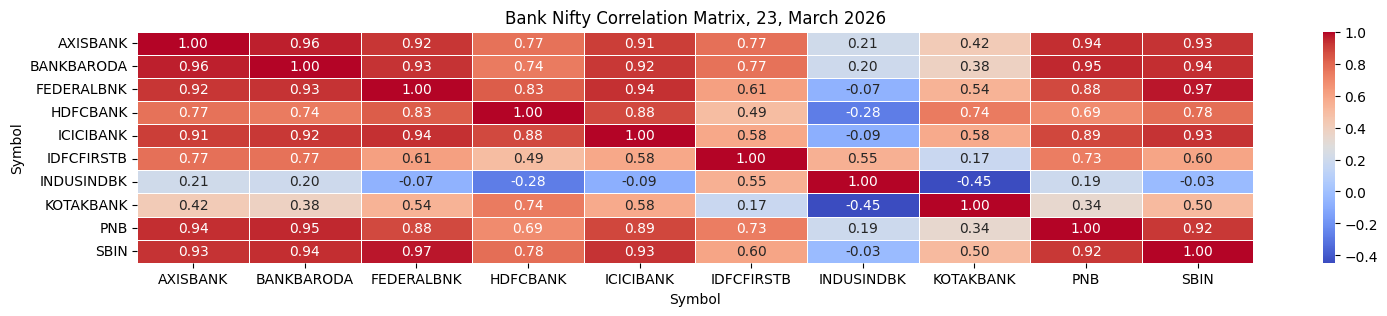

In [135]:
plt.figure(figsize=(18, 3))
sns.heatmap(cr.set_index('Symbol'), 
            annot=True,      
            cmap='coolwarm', 
            fmt='.2f',       
            linewidths=0.5)  

plt.title('Bank Nifty Correlation Matrix, 23, March 2026')
plt.show()